# 02 - Dashboard Interactivo de Business Intelligence

---

## Visualización Estática vs Interactiva

Mientras que Matplotlib y Seaborn son excelentes para análisis exploratorio y reportes estáticos, las herramientas interactivas como **Plotly** permiten:

- **Exploración dinámica**: zoom, pan, hover con detalles
- **Filtrado visual**: dropdowns, sliders, rangos de fechas
- **Comunicación efectiva**: gráficos que los stakeholders pueden explorar por sí mismos
- **Prototipado rápido**: de dashboards que luego se implementan en Grafana, Metabase o Looker

Este notebook construye un dashboard interactivo completo con 5 pestañas temáticas usando `plotly.graph_objects` y `plotly.express`.

### Pestañas del Dashboard

1. **Visión General de Flota**: composición, KPIs, mapa GPS
2. **Telemetría**: distribuciones, series temporales, patrones
3. **Insights de Clientes**: sunburst, satisfacción, embudo
4. **Analítica Predictiva**: importancia de features, predicciones, riesgo
5. **Alertas y Anomalías**: gauge de salud, timeline de anomalías

In [1]:
# === Configuración e importaciones ===
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Rutas del proyecto
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_raw = os.path.join(project_root, 'data', 'raw')
data_processed = os.path.join(project_root, 'data', 'processed')
models_dir = os.path.join(project_root, 'models')

# Colores del proyecto
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

print(f"Raíz del proyecto: {project_root}")
print("Plotly configurado para visualizaciones interactivas.")

Raíz del proyecto: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos
Plotly configurado para visualizaciones interactivas.


In [2]:
# === Carga de todos los datos ===

# Telemetría
telemetry_files = sorted(glob.glob(os.path.join(data_raw, 'telemetry', 'telemetry_*.csv')))
df_telemetry = pd.concat([pd.read_csv(f) for f in telemetry_files], ignore_index=True)
df_telemetry['timestamp'] = pd.to_datetime(df_telemetry['timestamp'])
df_telemetry['date'] = df_telemetry['timestamp'].dt.date
df_telemetry['hour'] = df_telemetry['timestamp'].dt.hour
df_telemetry['dayofweek'] = df_telemetry['timestamp'].dt.dayofweek
df_telemetry['day_name'] = df_telemetry['timestamp'].dt.day_name()

# Flota
df_fleet = pd.read_csv(os.path.join(data_raw, 'fleet_profiles.csv'))

# Encuestas
df_surveys = pd.read_csv(os.path.join(data_raw, 'surveys', 'buyer_surveys.csv'))

# Merge telemetría con tipo de vehículo
df_tel = df_telemetry.merge(df_fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Agregación por vehículo
vehicle_agg = df_tel.groupby(['vehicle_id', 'vehicle_type']).agg(
    speed_mean=('speed_kmh', 'mean'),
    speed_std=('speed_kmh', 'std'),
    accel_std=('acceleration_ms2', 'std'),
    consumption_mean=('fuel_consumption_rate', 'mean'),
    rpm_mean=('motor_rpm', 'mean'),
    power_mean=('motor_power_kw', 'mean'),
    battery_temp_mean=('battery_temp_c', 'mean'),
    battery_soc_mean=('battery_soc_pct', 'mean'),
    n_trips=('trip_id', 'nunique'),
    n_records=('timestamp', 'count'),
    lat_mean=('gps_lat', 'mean'),
    lon_mean=('gps_lon', 'mean')
).reset_index()

print(f"Registros de telemetría: {len(df_telemetry):,}")
print(f"Vehículos: {df_fleet.shape[0]}")
print(f"Encuestas: {df_surveys.shape[0]}")
print("Datos cargados exitosamente.")

Registros de telemetría: 6,076,720
Vehículos: 50
Encuestas: 500
Datos cargados exitosamente.


---

## Tab 1: Visión General de la Flota

Resumen ejecutivo interactivo con los KPIs principales, composición de flota y distribución geográfica.

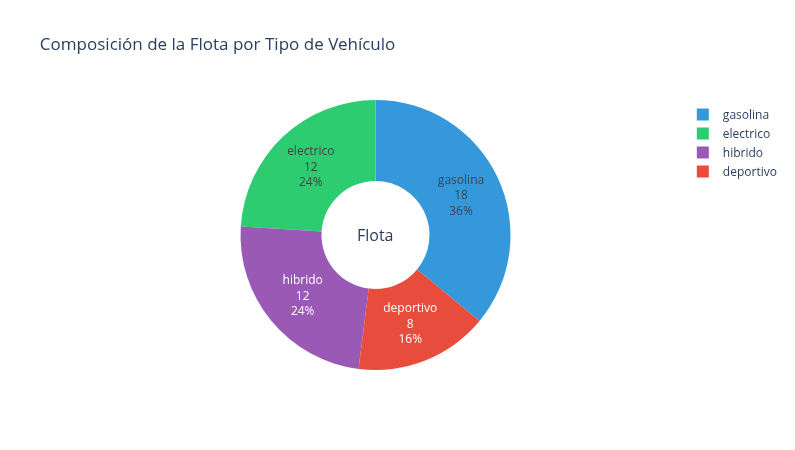

In [3]:
# === Tab 1: Pie chart - Tipos de vehículo ===

type_counts = df_fleet['vehicle_type'].value_counts()
colors_list = [vtype_colors.get(t, '#95a5a6') for t in type_counts.index]

fig_pie = go.Figure(data=[go.Pie(
    labels=type_counts.index,
    values=type_counts.values,
    hole=0.4,
    marker_colors=colors_list,
    textinfo='label+percent+value',
    hovertemplate='<b>%{label}</b><br>Cantidad: %{value}<br>Porcentaje: %{percent}<extra></extra>'
)])

fig_pie.update_layout(
    title_text='Composición de la Flota por Tipo de Vehículo',
    template='plotly_white',
    height=450,
    annotations=[dict(text='Flota', x=0.5, y=0.5, font_size=16, showarrow=False)]
)
fig_pie.show()

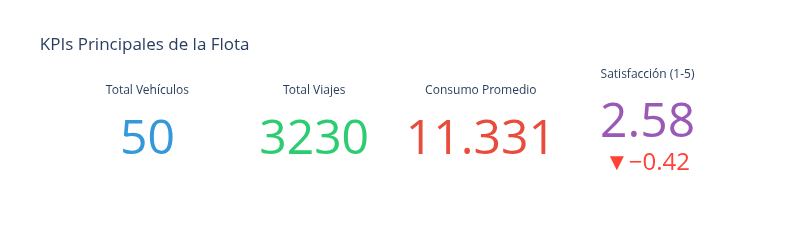

In [4]:
# === Tab 1: Indicator cards ===

total_vehicles = len(df_fleet)
total_trips = df_telemetry['trip_id'].nunique()
avg_consumption = df_tel['fuel_consumption_rate'].mean()
avg_satisfaction = df_surveys['satisfaction_score'].mean()

fig_indicators = make_subplots(
    rows=1, cols=4,
    specs=[[{'type': 'indicator'}]*4]
)

fig_indicators.add_trace(go.Indicator(
    mode='number', value=total_vehicles,
    title={'text': 'Total Vehículos'},
    number={'font': {'size': 48, 'color': '#3498db'}}
), row=1, col=1)

fig_indicators.add_trace(go.Indicator(
    mode='number', value=total_trips,
    title={'text': 'Total Viajes'},
    number={'font': {'size': 48, 'color': '#2ecc71'}}
), row=1, col=2)

fig_indicators.add_trace(go.Indicator(
    mode='number', value=avg_consumption,
    title={'text': 'Consumo Promedio'},
    number={'font': {'size': 48, 'color': '#e74c3c'}, 'valueformat': '.3f'}
), row=1, col=3)

fig_indicators.add_trace(go.Indicator(
    mode='number+delta', value=avg_satisfaction,
    title={'text': 'Satisfacción (1-5)'},
    delta={'reference': 3.0, 'valueformat': '.2f'},
    number={'font': {'size': 48, 'color': '#9b59b6'}, 'valueformat': '.2f'}
), row=1, col=4)

fig_indicators.update_layout(
    title_text='KPIs Principales de la Flota',
    template='plotly_white',
    height=250
)
fig_indicators.show()

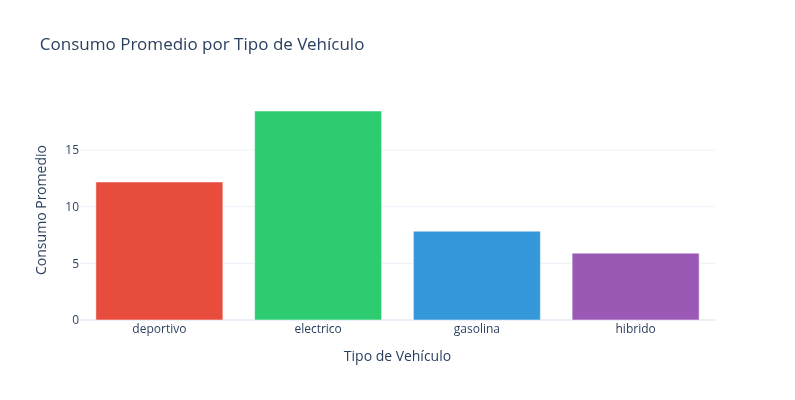

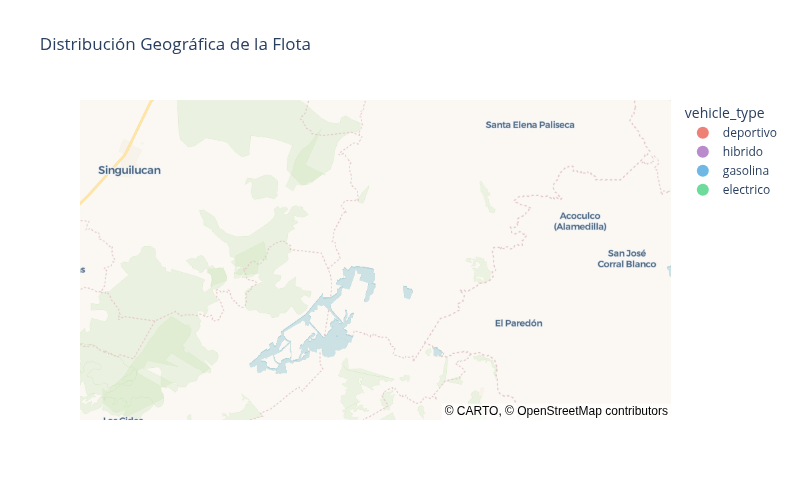

In [5]:
# === Tab 1: Bar chart consumo por tipo + Scatter map GPS ===

# Bar chart consumo por tipo
consumption_by_type = df_tel.groupby('vehicle_type')['fuel_consumption_rate'].mean().reset_index()
consumption_by_type.columns = ['vehicle_type', 'avg_consumption']

fig_bar = px.bar(
    consumption_by_type, x='vehicle_type', y='avg_consumption',
    color='vehicle_type', color_discrete_map=vtype_colors,
    title='Consumo Promedio por Tipo de Vehículo',
    labels={'vehicle_type': 'Tipo de Vehículo', 'avg_consumption': 'Consumo Promedio'},
    template='plotly_white'
)
fig_bar.update_traces(hovertemplate='<b>%{x}</b><br>Consumo: %{y:.4f}<extra></extra>')
fig_bar.update_layout(height=400, showlegend=False)
fig_bar.show()

# Scatter map con posiciones GPS promedio
fig_map = px.scatter_map(
    vehicle_agg, lat='lat_mean', lon='lon_mean',
    color='vehicle_type', color_discrete_map=vtype_colors,
    size='n_trips', size_max=15,
    hover_name='vehicle_id',
    hover_data={'consumption_mean': ':.3f', 'speed_mean': ':.1f', 'n_trips': True},
    title='Distribución Geográfica de la Flota',
    template='plotly_white',
    zoom=10
)
fig_map.update_layout(height=500)
fig_map.show()

---

## Tab 2: Telemetría

Exploración interactiva de las métricas de telemetría: distribuciones, series temporales y patrones de uso.

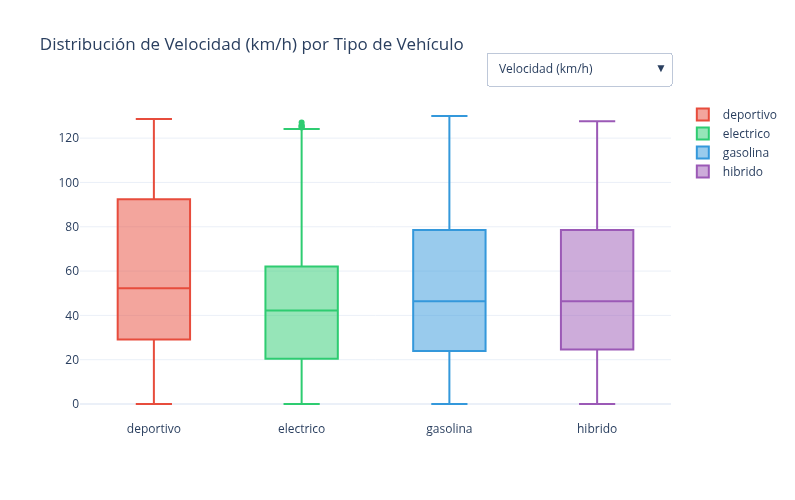

In [6]:
# === Tab 2: Box plot con dropdown (velocidad, consumo, temperatura, RPM) ===

metrics_config = {
    'speed_kmh': 'Velocidad (km/h)',
    'fuel_consumption_rate': 'Consumo de Combustible',
    'battery_temp_c': 'Temperatura Batería (°C)',
    'motor_rpm': 'RPM del Motor'
}

fig_box = go.Figure()

# Crear un box plot por cada tipo de vehículo para cada métrica
first = True
for metric, label in metrics_config.items():
    for vtype in sorted(df_tel['vehicle_type'].unique()):
        data = df_tel[df_tel['vehicle_type'] == vtype][metric].dropna()
        # Tomar muestra si hay muchos datos
        if len(data) > 5000:
            data = data.sample(5000, random_state=42)
        fig_box.add_trace(go.Box(
            y=data, name=vtype,
            marker_color=vtype_colors.get(vtype, '#95a5a6'),
            visible=first,
            hovertemplate=f'<b>{vtype}</b><br>{label}: ' + '%{y:.2f}<extra></extra>'
        ))
    first = False

n_types = len(df_tel['vehicle_type'].unique())
n_metrics = len(metrics_config)

# Crear botones de dropdown
buttons = []
for i, (metric, label) in enumerate(metrics_config.items()):
    visibility = [False] * (n_types * n_metrics)
    for j in range(n_types):
        visibility[i * n_types + j] = True
    buttons.append(dict(
        method='update',
        label=label,
        args=[{'visible': visibility},
              {'title': f'Distribución de {label} por Tipo de Vehículo'}]
    ))

fig_box.update_layout(
    title='Distribución de Velocidad (km/h) por Tipo de Vehículo',
    template='plotly_white',
    height=500,
    updatemenus=[dict(
        type='dropdown', direction='down',
        x=1.0, y=1.15, showactive=True,
        buttons=buttons
    )]
)
fig_box.show()

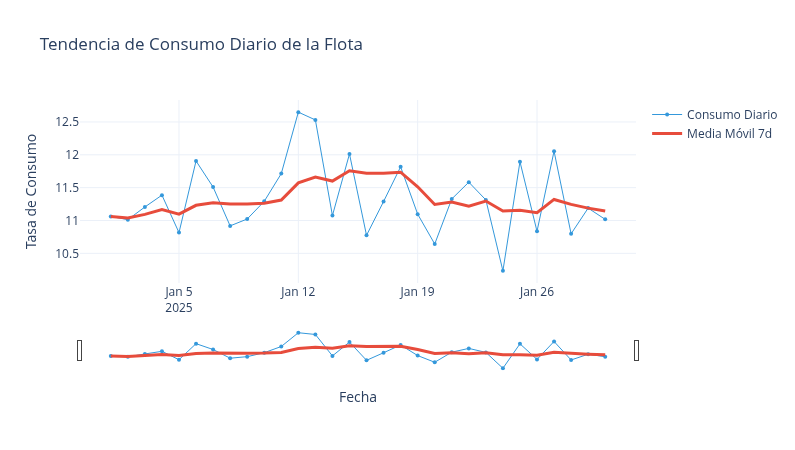

In [7]:
# === Tab 2: Serie temporal de consumo diario con rangeslider ===

daily_consumption = df_tel.groupby('date')['fuel_consumption_rate'].mean().reset_index()
daily_consumption['date'] = pd.to_datetime(daily_consumption['date'])
daily_consumption = daily_consumption.sort_values('date')
daily_consumption['rolling_7d'] = daily_consumption['fuel_consumption_rate'].rolling(7, min_periods=1).mean()

fig_ts = go.Figure()
fig_ts.add_trace(go.Scatter(
    x=daily_consumption['date'], y=daily_consumption['fuel_consumption_rate'],
    mode='lines+markers', name='Consumo Diario',
    line=dict(color='#3498db', width=1), marker=dict(size=4),
    hovertemplate='<b>%{x|%Y-%m-%d}</b><br>Consumo: %{y:.4f}<extra></extra>'
))
fig_ts.add_trace(go.Scatter(
    x=daily_consumption['date'], y=daily_consumption['rolling_7d'],
    mode='lines', name='Media Móvil 7d',
    line=dict(color='#e74c3c', width=3),
    hovertemplate='<b>%{x|%Y-%m-%d}</b><br>Media 7d: %{y:.4f}<extra></extra>'
))

fig_ts.update_layout(
    title='Tendencia de Consumo Diario de la Flota',
    template='plotly_white',
    height=450,
    xaxis=dict(
        rangeslider=dict(visible=True),
        type='date',
        title='Fecha'
    ),
    yaxis_title='Tasa de Consumo'
)
fig_ts.show()

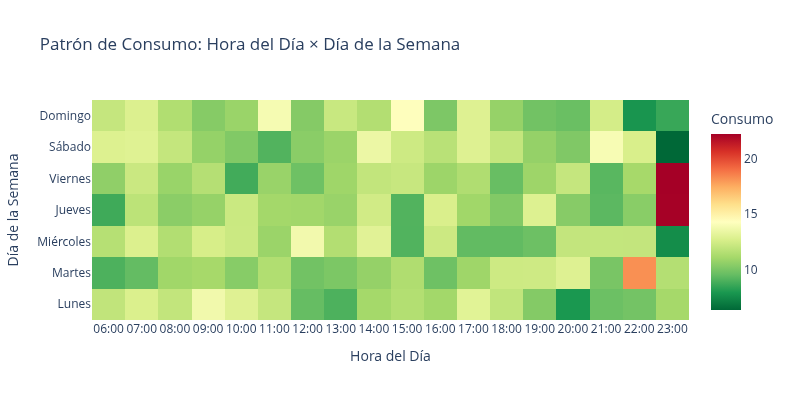

In [8]:
# === Tab 2: Heatmap hora × día de la semana ===

heatmap_data = df_tel.groupby(['dayofweek', 'hour'])['fuel_consumption_rate'].mean().reset_index()
heatmap_pivot = heatmap_data.pivot(index='dayofweek', columns='hour', values='fuel_consumption_rate')

day_labels = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

fig_hm = go.Figure(data=go.Heatmap(
    z=heatmap_pivot.values,
    x=[f'{h:02d}:00' for h in heatmap_pivot.columns],
    y=day_labels,
    colorscale='RdYlGn_r',
    hovertemplate='<b>%{y} - %{x}</b><br>Consumo: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Consumo')
))

fig_hm.update_layout(
    title='Patrón de Consumo: Hora del Día × Día de la Semana',
    template='plotly_white',
    height=400,
    xaxis_title='Hora del Día',
    yaxis_title='Día de la Semana'
)
fig_hm.show()

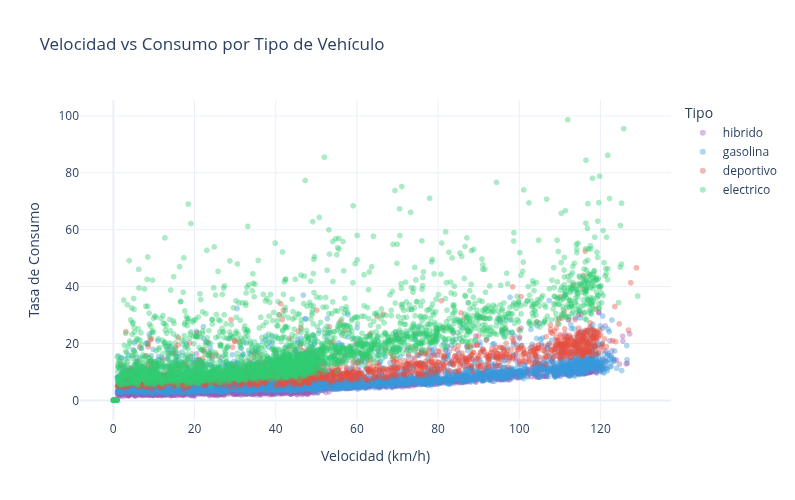

In [9]:
# === Tab 2: Scatter velocidad vs consumo por tipo ===

# Muestra para rendimiento
sample_tel = df_tel.sample(min(10000, len(df_tel)), random_state=42)

fig_scatter = px.scatter(
    sample_tel, x='speed_kmh', y='fuel_consumption_rate',
    color='vehicle_type', color_discrete_map=vtype_colors,
    opacity=0.4, size_max=8,
    title='Velocidad vs Consumo por Tipo de Vehículo',
    labels={'speed_kmh': 'Velocidad (km/h)', 'fuel_consumption_rate': 'Tasa de Consumo',
            'vehicle_type': 'Tipo'},
    template='plotly_white',
    hover_data={'vehicle_id': True, 'road_type': True}
)
fig_scatter.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Velocidad: %{x:.1f} km/h<br>Consumo: %{y:.4f}<br>Vía: %{customdata[1]}<extra></extra>'
)
fig_scatter.update_layout(height=500)
fig_scatter.show()

---

## Tab 3: Insights de Clientes

Exploración interactiva de los datos de encuestas de compradores, segmentación y satisfacción.

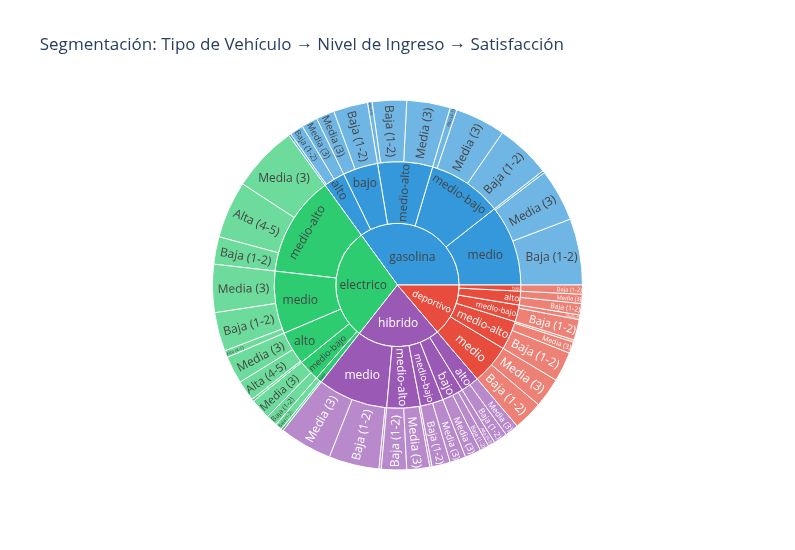

In [10]:
# === Tab 3: Sunburst tipo → ingreso → satisfacción ===

# Crear categorías de satisfacción
df_sun = df_surveys.copy()
df_sun['sat_category'] = pd.cut(df_sun['satisfaction_score'],
                                 bins=[0, 2, 3, 5],
                                 labels=['Baja (1-2)', 'Media (3)', 'Alta (4-5)'])

sunburst_data = df_sun.groupby(['vehicle_type_purchased', 'income_bracket', 'sat_category']).size().reset_index(name='count')

fig_sun = px.sunburst(
    sunburst_data,
    path=['vehicle_type_purchased', 'income_bracket', 'sat_category'],
    values='count',
    color='vehicle_type_purchased',
    color_discrete_map=vtype_colors,
    title='Segmentación: Tipo de Vehículo → Nivel de Ingreso → Satisfacción',
    template='plotly_white'
)
fig_sun.update_traces(hovertemplate='<b>%{label}</b><br>Encuestas: %{value}<br>Porcentaje: %{percentRoot:.1%}<extra></extra>')
fig_sun.update_layout(height=550)
fig_sun.show()

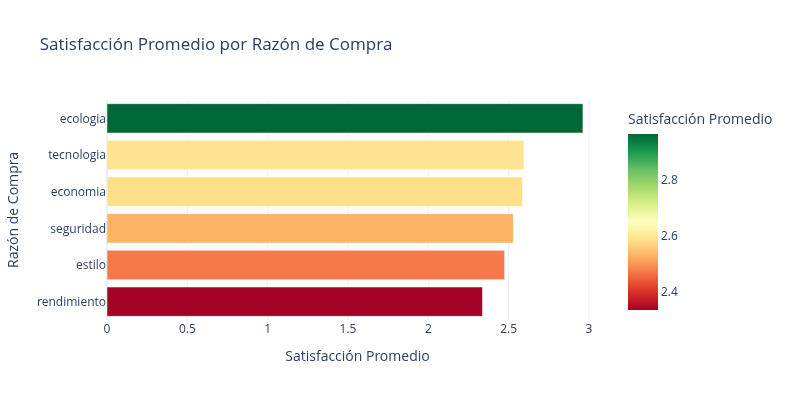

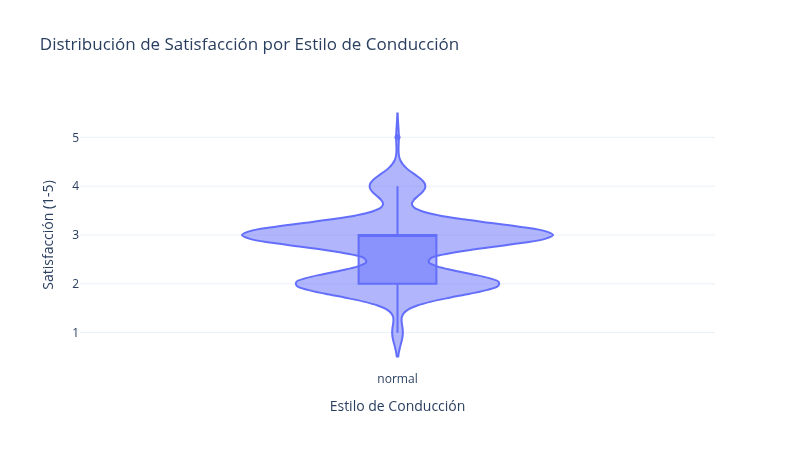

In [11]:
# === Tab 3: Satisfacción por purchase_reason + Violin por driving_style ===

# Bar: satisfacción por razón de compra
sat_reason = df_surveys.groupby('purchase_reason')['satisfaction_score'].mean().sort_values(ascending=True).reset_index()

fig_reason = px.bar(
    sat_reason, x='satisfaction_score', y='purchase_reason',
    orientation='h',
    title='Satisfacción Promedio por Razón de Compra',
    labels={'satisfaction_score': 'Satisfacción Promedio', 'purchase_reason': 'Razón de Compra'},
    template='plotly_white',
    color='satisfaction_score',
    color_continuous_scale='RdYlGn'
)
fig_reason.update_traces(hovertemplate='<b>%{y}</b><br>Satisfacción: %{x:.2f}<extra></extra>')
fig_reason.update_layout(height=400)
fig_reason.show()

# Violin: satisfacción por estilo de conducción
style_order = ['conservador', 'normal', 'agresivo', 'muy_agresivo']
df_violin = df_surveys.copy()
df_violin['driving_style'] = pd.Categorical(df_violin['driving_style'], categories=style_order, ordered=True)

fig_violin = px.violin(
    df_violin.sort_values('driving_style'), x='driving_style', y='satisfaction_score',
    color='driving_style',
    box=True, points='outliers',
    title='Distribución de Satisfacción por Estilo de Conducción',
    labels={'driving_style': 'Estilo de Conducción', 'satisfaction_score': 'Satisfacción (1-5)'},
    template='plotly_white'
)
fig_violin.update_traces(hovertemplate='<b>%{x}</b><br>Satisfacción: %{y}<extra></extra>')
fig_violin.update_layout(height=450, showlegend=False)
fig_violin.show()

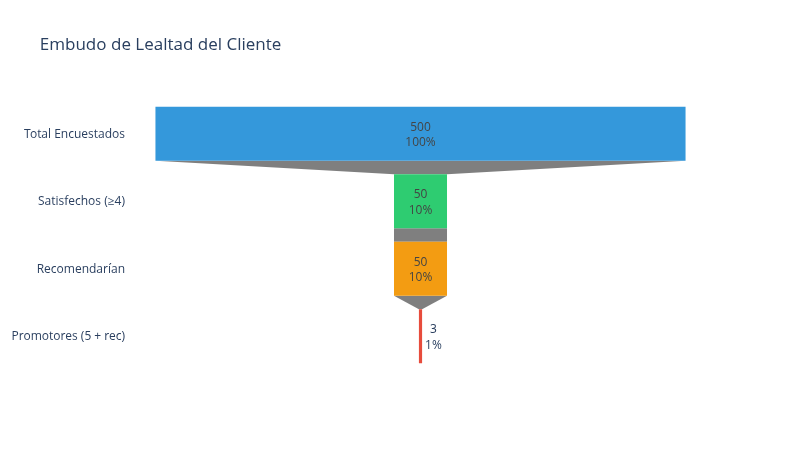

In [12]:
# === Tab 3: Funnel (total → satisfechos → recomendarían) ===

total = len(df_surveys)
satisfied = len(df_surveys[df_surveys['satisfaction_score'] >= 4])
would_rec = len(df_surveys[(df_surveys['satisfaction_score'] >= 4) & (df_surveys['would_recommend'] == 1)])
promoters = len(df_surveys[(df_surveys['satisfaction_score'] == 5) & (df_surveys['would_recommend'] == 1)])

fig_funnel = go.Figure(go.Funnel(
    y=['Total Encuestados', 'Satisfechos (≥4)', 'Recomendarían', 'Promotores (5 + rec)'],
    x=[total, satisfied, would_rec, promoters],
    textinfo='value+percent initial',
    marker=dict(color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c']),
    hovertemplate='<b>%{y}</b><br>Cantidad: %{x}<br>Del total: %{percentInitial:.1%}<extra></extra>'
))

fig_funnel.update_layout(
    title='Embudo de Lealtad del Cliente',
    template='plotly_white',
    height=450
)
fig_funnel.show()

---

## Tab 4: Analítica Predictiva

Resultados de los modelos de Machine Learning: importancia de features, predicciones y clasificación de riesgo.

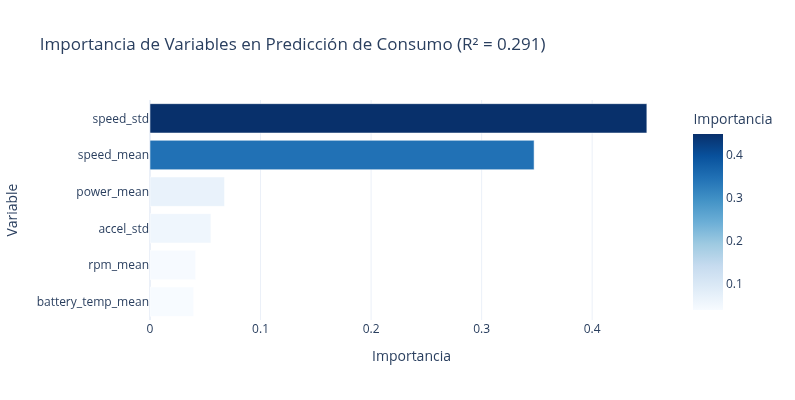

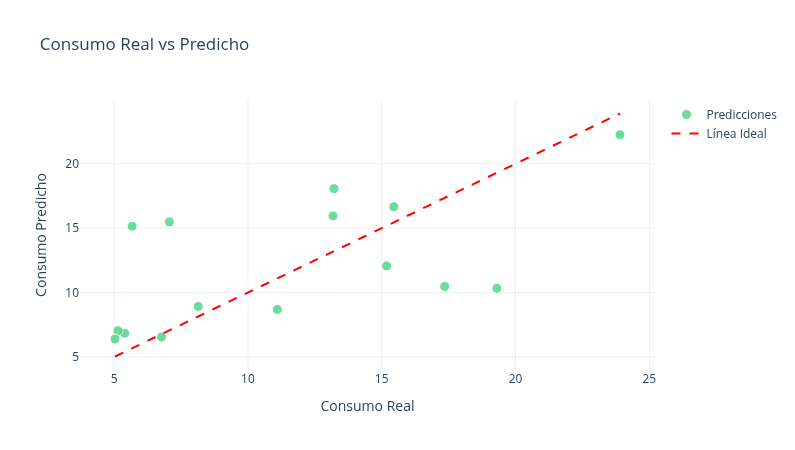

In [13]:
# === Tab 4: Modelo predictivo ===

# Entrenar un RF rápido
model_features = ['speed_mean', 'speed_std', 'accel_std', 'rpm_mean', 'power_mean', 'battery_temp_mean']
df_model = vehicle_agg[model_features + ['consumption_mean']].dropna()

X = df_model[model_features]
y = df_model['consumption_mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)

# Horizontal bar: feature importance
importance = pd.DataFrame({
    'feature': model_features,
    'importance': rf.feature_importances_
}).sort_values('importance')

fig_imp = px.bar(
    importance, x='importance', y='feature', orientation='h',
    title=f'Importancia de Variables en Predicción de Consumo (R² = {r2:.3f})',
    labels={'importance': 'Importancia', 'feature': 'Variable'},
    template='plotly_white',
    color='importance', color_continuous_scale='Blues'
)
fig_imp.update_traces(hovertemplate='<b>%{y}</b><br>Importancia: %{x:.4f}<extra></extra>')
fig_imp.update_layout(height=400)
fig_imp.show()

# Scatter: actual vs predicho
fig_pred = go.Figure()
fig_pred.add_trace(go.Scatter(
    x=y_test.values, y=y_pred, mode='markers',
    marker=dict(color='#2ecc71', size=10, opacity=0.7, line=dict(width=1, color='white')),
    name='Predicciones',
    hovertemplate='Real: %{x:.4f}<br>Predicho: %{y:.4f}<extra></extra>'
))
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
fig_pred.add_trace(go.Scatter(
    x=[min_v, max_v], y=[min_v, max_v], mode='lines',
    line=dict(color='red', dash='dash', width=2), name='Línea Ideal'
))
fig_pred.update_layout(
    title='Consumo Real vs Predicho',
    xaxis_title='Consumo Real', yaxis_title='Consumo Predicho',
    template='plotly_white', height=450
)
fig_pred.show()

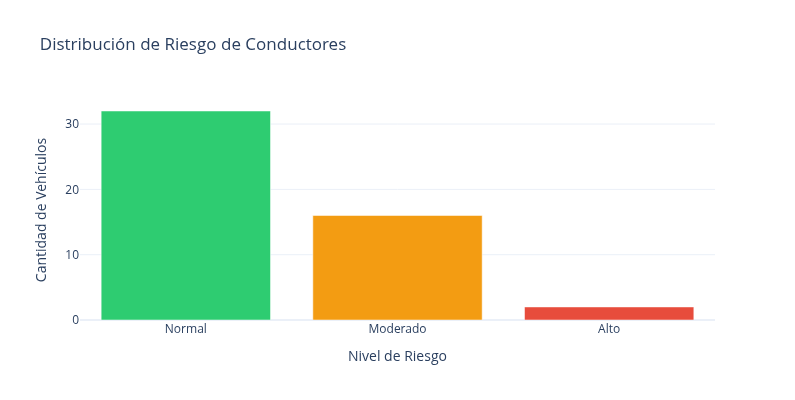

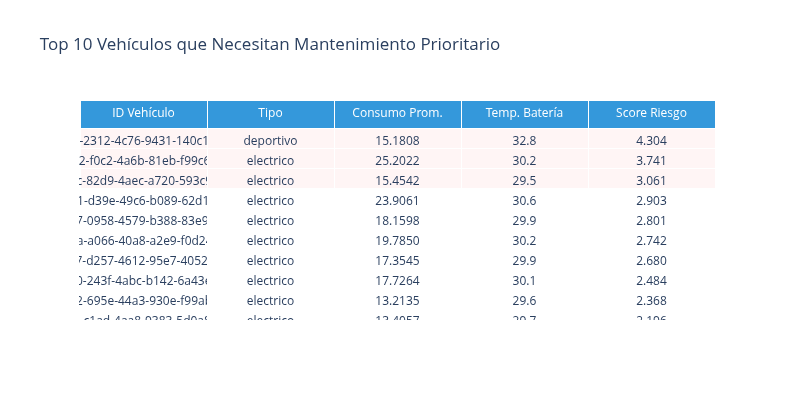

In [14]:
# === Tab 4: Distribución de riesgo + Top 10 vehículos mantenimiento ===

# Calcular riesgo por vehículo
harsh_braking = df_tel.groupby('vehicle_id')['acceleration_ms2'].apply(
    lambda x: (x < x.quantile(0.05)).sum()
).reset_index(name='harsh_braking_count')

risk_df = vehicle_agg[['vehicle_id', 'vehicle_type', 'speed_std']].merge(harsh_braking, on='vehicle_id')
brake_thresh = risk_df['harsh_braking_count'].quantile(0.80)
speed_thresh = risk_df['speed_std'].quantile(0.80)

risk_df['risk'] = 'Normal'
risk_df.loc[(risk_df['harsh_braking_count'] >= brake_thresh) | (risk_df['speed_std'] >= speed_thresh), 'risk'] = 'Moderado'
risk_df.loc[(risk_df['harsh_braking_count'] >= brake_thresh) & (risk_df['speed_std'] >= speed_thresh), 'risk'] = 'Alto'

risk_counts = risk_df['risk'].value_counts().reset_index()
risk_counts.columns = ['risk', 'count']
risk_color_map = {'Normal': '#2ecc71', 'Moderado': '#f39c12', 'Alto': '#e74c3c'}

fig_risk = px.bar(
    risk_counts, x='risk', y='count',
    color='risk', color_discrete_map=risk_color_map,
    title='Distribución de Riesgo de Conductores',
    labels={'risk': 'Nivel de Riesgo', 'count': 'Cantidad de Vehículos'},
    template='plotly_white'
)
fig_risk.update_traces(hovertemplate='<b>%{x}</b><br>Vehículos: %{y}<extra></extra>')
fig_risk.update_layout(height=400, showlegend=False)
fig_risk.show()

# Tabla: top 10 vehículos que necesitan mantenimiento
# Basado en z-score de consumo y temperatura
maint_df = vehicle_agg[['vehicle_id', 'vehicle_type', 'consumption_mean', 'battery_temp_mean']].copy()
maint_df['z_consumption'] = np.abs(stats.zscore(maint_df['consumption_mean'].fillna(0)))
maint_df['z_battery_temp'] = np.abs(stats.zscore(maint_df['battery_temp_mean'].fillna(0)))
maint_df['risk_score'] = maint_df['z_consumption'] + maint_df['z_battery_temp']
top_maint = maint_df.nlargest(10, 'risk_score')[['vehicle_id', 'vehicle_type', 'consumption_mean', 'battery_temp_mean', 'risk_score']]
top_maint.columns = ['ID Vehículo', 'Tipo', 'Consumo Prom.', 'Temp. Batería', 'Score Riesgo']

fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(top_maint.columns),
                fill_color='#3498db', font=dict(color='white', size=12),
                align='center'),
    cells=dict(values=[top_maint[c] for c in top_maint.columns],
               fill_color=[['#fff5f5' if i < 3 else '#ffffff' for i in range(len(top_maint))]]*len(top_maint.columns),
               align='center',
               format=[None, None, '.4f', '.1f', '.3f'])
)])
fig_table.update_layout(
    title='Top 10 Vehículos que Necesitan Mantenimiento Prioritario',
    template='plotly_white', height=400
)
fig_table.show()

---

## Tab 5: Alertas y Anomalías

Monitoreo del estado de salud de la flota, detección de anomalías y sistema de alertas.

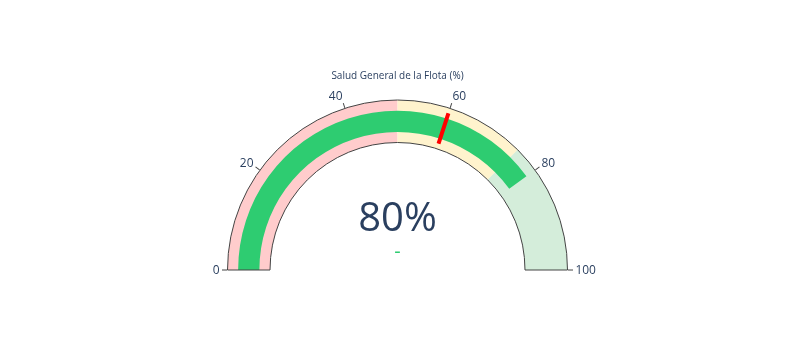

In [15]:
# === Tab 5: Gauge de salud de la flota ===

# Calcular salud general
health_df = vehicle_agg[['vehicle_id', 'consumption_mean', 'battery_temp_mean']].copy()
health_df['z_consumption'] = np.abs(stats.zscore(health_df['consumption_mean'].fillna(0)))
health_df['z_battery_temp'] = np.abs(stats.zscore(health_df['battery_temp_mean'].fillna(0)))
health_df['max_z'] = health_df[['z_consumption', 'z_battery_temp']].max(axis=1)

pct_healthy = (health_df['max_z'] < 1.5).sum() / len(health_df) * 100

fig_gauge = go.Figure(go.Indicator(
    mode='gauge+number+delta',
    value=pct_healthy,
    delta={'reference': 80, 'increasing': {'color': '#2ecc71'}, 'decreasing': {'color': '#e74c3c'}},
    title={'text': 'Salud General de la Flota (%)'},
    number={'suffix': '%', 'font': {'size': 40}},
    gauge=dict(
        axis=dict(range=[0, 100]),
        bar=dict(color='#2ecc71'),
        steps=[
            dict(range=[0, 50], color='#ffcccc'),
            dict(range=[50, 75], color='#fff3cd'),
            dict(range=[75, 100], color='#d4edda')
        ],
        threshold=dict(line=dict(color='red', width=4), thickness=0.75, value=60)
    )
))
fig_gauge.update_layout(template='plotly_white', height=350)
fig_gauge.show()

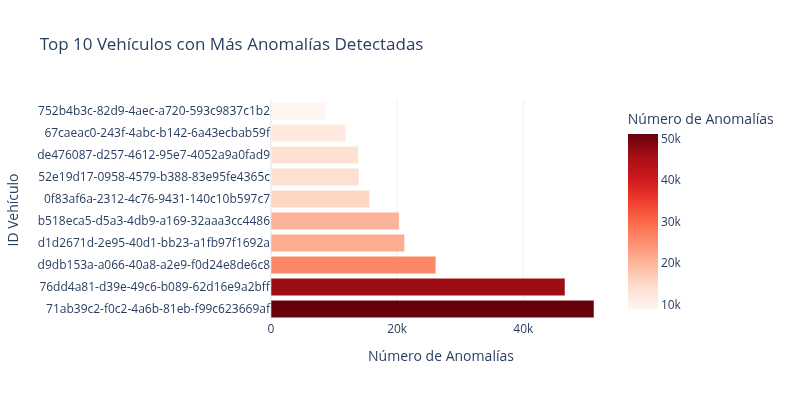

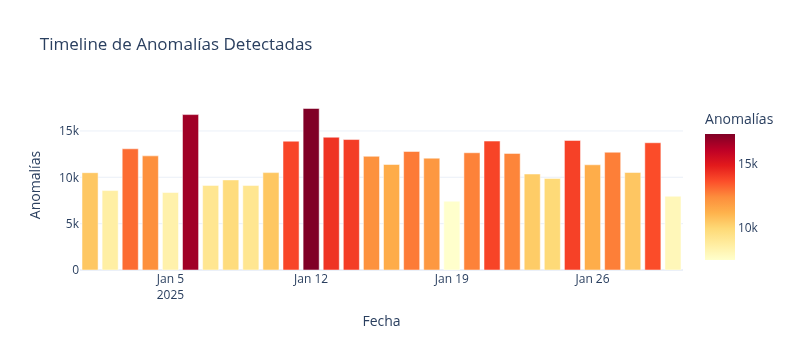

In [16]:
# === Tab 5: Conteo de anomalías por vehículo (top 10) + Timeline ===

# Detectar anomalías por registro (z-score > 2.5 en consumo o temp)
df_anomalies = df_tel[['timestamp', 'vehicle_id', 'vehicle_type', 'fuel_consumption_rate', 'battery_temp_c']].copy()

for col in ['fuel_consumption_rate', 'battery_temp_c']:
    mean_val = df_anomalies[col].mean()
    std_val = df_anomalies[col].std()
    df_anomalies[f'z_{col}'] = np.abs((df_anomalies[col] - mean_val) / std_val)

df_anomalies['is_anomaly'] = (
    (df_anomalies['z_fuel_consumption_rate'] > 2.5) |
    (df_anomalies['z_battery_temp_c'] > 2.5)
)

anomaly_count = df_anomalies[df_anomalies['is_anomaly']].groupby('vehicle_id').size().nlargest(10).reset_index(name='anomalies')

fig_anom_bar = px.bar(
    anomaly_count, x='anomalies', y='vehicle_id', orientation='h',
    title='Top 10 Vehículos con Más Anomalías Detectadas',
    labels={'anomalies': 'Número de Anomalías', 'vehicle_id': 'ID Vehículo'},
    template='plotly_white',
    color='anomalies', color_continuous_scale='Reds'
)
fig_anom_bar.update_traces(hovertemplate='<b>%{y}</b><br>Anomalías: %{x}<extra></extra>')
fig_anom_bar.update_layout(height=400)
fig_anom_bar.show()

# Timeline de anomalías
anomalies_daily = df_anomalies[df_anomalies['is_anomaly']].copy()
anomalies_daily['date'] = anomalies_daily['timestamp'].dt.date
anom_timeline = anomalies_daily.groupby('date').size().reset_index(name='count')
anom_timeline['date'] = pd.to_datetime(anom_timeline['date'])

fig_timeline = px.bar(
    anom_timeline, x='date', y='count',
    title='Timeline de Anomalías Detectadas',
    labels={'date': 'Fecha', 'count': 'Anomalías'},
    template='plotly_white',
    color='count', color_continuous_scale='YlOrRd'
)
fig_timeline.update_traces(hovertemplate='<b>%{x|%Y-%m-%d}</b><br>Anomalías: %{y}<extra></extra>')
fig_timeline.update_layout(height=350)
fig_timeline.show()

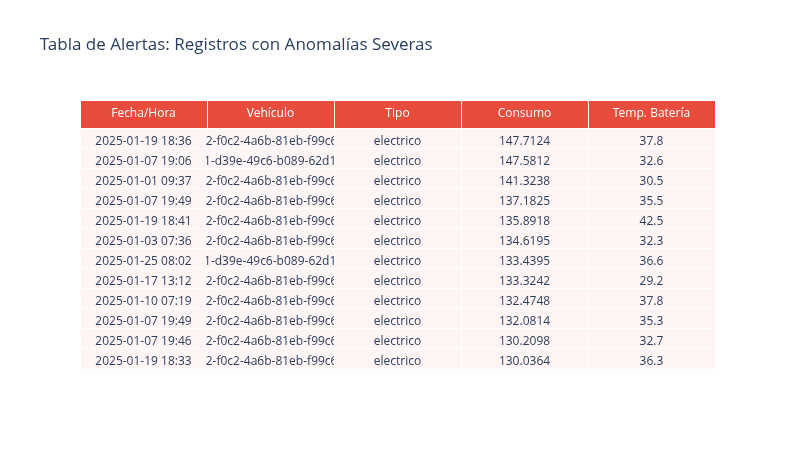


Total de anomalías detectadas: 353,248 (5.81% de registros)
Vehículos afectados: 50


In [17]:
# === Tab 5: Tabla de alertas ===

# Generar tabla de alertas con los peores registros
alert_records = df_anomalies[df_anomalies['is_anomaly']].nlargest(15, 'z_fuel_consumption_rate')
alert_table = alert_records[['timestamp', 'vehicle_id', 'vehicle_type',
                              'fuel_consumption_rate', 'battery_temp_c']].copy()
alert_table['timestamp'] = alert_table['timestamp'].dt.strftime('%Y-%m-%d %H:%M')
alert_table.columns = ['Fecha/Hora', 'Vehículo', 'Tipo', 'Consumo', 'Temp. Batería']

fig_alerts = go.Figure(data=[go.Table(
    header=dict(
        values=list(alert_table.columns),
        fill_color='#e74c3c', font=dict(color='white', size=12),
        align='center'
    ),
    cells=dict(
        values=[alert_table[c] for c in alert_table.columns],
        fill_color='#fff5f5',
        align='center',
        format=[None, None, None, '.4f', '.1f']
    )
)])

fig_alerts.update_layout(
    title='Tabla de Alertas: Registros con Anomalías Severas',
    template='plotly_white', height=450
)
fig_alerts.show()

total_anomalies = df_anomalies['is_anomaly'].sum()
pct_anomalies = df_anomalies['is_anomaly'].mean() * 100
print(f"\nTotal de anomalías detectadas: {total_anomalies:,} ({pct_anomalies:.2f}% de registros)")
print(f"Vehículos afectados: {df_anomalies[df_anomalies['is_anomaly']]['vehicle_id'].nunique()}")

---

## Resumen: Del Prototipo a Producción

Este dashboard interactivo demuestra las capacidades analíticas que se pueden implementar en herramientas de producción:

| Componente de este notebook | Herramienta de producción |
|----------------------------|-------------------------|
| Plotly indicators/gauges | **Grafana** dashboards con alertas en tiempo real |
| Gráficos interactivos | **Looker** / **Metabase** para self-service analytics |
| Tablas de anomalías | **PagerDuty** / **Opsgenie** para alertas operativas |
| Mapas GPS | **Grafana** con plugin de mapas o **Kepler.gl** |
| Modelos ML | **MLflow** + **FastAPI** para predicciones en tiempo real |

### Siguiente paso

Consulta el notebook **[03_pipeline_documentation.ipynb](03_pipeline_documentation.ipynb)** para la documentación completa del pipeline y el plan de implementación en producción.

---

*Proyecto de Ciencia de Datos - Fase 6: Dashboard Interactivo*